# CPU-GPU Test of `DemodHilbert2D`

This notebook replicates in Python/NumPy the MATLAB test script `testDemodHilbert2D.m` for the 2D Hilbert demodulation function `DemodHilbert2D`. The test generates a synthetic interferogram and checks that the phase RMSE after demodulation is below 0.02 rad.
Here we check NumPy-CPU and TensorFlow-GPU implementations

In [1]:
# ---
# ✅ Colab bootstrap for LensPMD
# How to open in Colab:
# 1) Clone the LensPMD repo into Google Drive.
# 2) In Drive (web), right-click the notebook → “Open with” → “Google Colab”.
# 3) Run this cell to mount Drive, set the working directory, and verify required paths.
# ---

import os
from pathlib import Path

# === Detect Colab =============================================================
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab? {IN_COLAB}")

# === Setup when in Colab ======================================================
if IN_COLAB:
    from google.colab import drive  # type: ignore
    DRIVE_MOUNT_POINT = "/content/drive"
    PROJECT_REL_PATH = "MyDrive/Colab Notebooks/72_OM4M008_LENSPMD25_CPU_GPU_FPA/Python_src"
    REQUIRED_PATH = "/content/drive/MyDrive/Colab Notebooks/72_OM4M008_LENSPMD25_CPU_GPU_FPA/local_data"

    # Mount Google Drive
    drive.mount(DRIVE_MOUNT_POINT, force_remount=True)

    # Set working directory
    project_path = Path(DRIVE_MOUNT_POINT) / PROJECT_REL_PATH
    if not project_path.exists():
        raise FileNotFoundError(f"❌ Project directory not found: {project_path}")

    os.chdir(project_path)
    print("✅ Working Directory:", Path.cwd())

    # Verify required local_data folder exists
    local_data_path = Path(REQUIRED_PATH)
    if not local_data_path.exists():
        raise FileNotFoundError(
            f"❌ Required directory not found: {local_data_path}\n"
            "Please ensure 'local_data' exists in the LensPMD folder in your Drive."
        )

    print("✅ Required folder found:", local_data_path)
    print("📂 Files in Working Directory:", os.listdir())

else:
    print("Not running in Colab — skipping Drive mount and WD setup.")
    print("Current Working Directory:", Path.cwd())


Running in Colab? False
Not running in Colab — skipping Drive mount and WD setup.
Current Working Directory: c:\user\AQ_SCC\72_OM4M008_LENSPMD25_CPU_GPU_FPA\Python_src


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from FPA_Numpy import DemodHilbert2D_NumPy
from FPA_TensorFlow import DemodHilbert2D_TF
from FPA_Utils import peaks_2d, time_function

from functools import partial


c:\ProgramData\anaconda3\envs\LENSPMD25-base310\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [3]:
# Synthetic interferogram (Caso 1: HIFREQ)
NR, NC = 558, 553
y, x = np.meshgrid(
    np.arange(NR, dtype=np.float32),
    np.arange(NC, dtype=np.float32),
    indexing="ij",
)
x = x - 0.5 * NC
y = y - 0.5 * NR

M = np.ones((NR, NC), dtype=np.float32)

w0 = np.array([0.5*np.pi/4, 0.5*np.pi/4], dtype=np.float32)
fringe_carrier_or = np.arctan2(w0[1], w0[0])

# Smooth phase term
phi_0 = 3.0 * peaks_2d(NR, NC)
phi = phi_0 + w0[0] * x + w0[1] * y

# Ground-truth spatial frequencies (not used in the test assertion)
phi_x, phi_y = np.gradient(phi.astype(np.float32))
w_phi = np.abs(phi_x + 1j * phi_y) * M
theta_or = np.arctan2(-phi_y, phi_x)

# DC and modulation in gray values
b = np.float32(100.0)
m = np.float32(64.0)
nL_mod = np.float32(0.0)

# Interferogram g in [0,255]
g_float = b + m * np.cos(phi) + nL_mod * np.random.randn(NR, NC).astype(np.float32)
g_uint8 = np.clip(np.round(g_float), 0, 255).astype(np.uint8)
g = g_uint8.astype(np.float32) * M

# Ground-truth complex phasor
z = b * np.exp(1j * phi)
print("Synthetic interferogram generated.")


Synthetic interferogram generated.


[DemodHilbert2D_NumPy] Warm-up time: 33.02 ms
[DemodHilbert2D_NumPy] Run 1/10: 31.59 ms
[DemodHilbert2D_NumPy] Run 2/10: 27.34 ms
[DemodHilbert2D_NumPy] Run 3/10: 28.97 ms
[DemodHilbert2D_NumPy] Run 4/10: 29.68 ms
[DemodHilbert2D_NumPy] Run 5/10: 28.97 ms
[DemodHilbert2D_NumPy] Run 6/10: 27.85 ms
[DemodHilbert2D_NumPy] Run 7/10: 33.58 ms
[DemodHilbert2D_NumPy] Run 8/10: 36.91 ms
[DemodHilbert2D_NumPy] Run 9/10: 34.43 ms
[DemodHilbert2D_NumPy] Run 10/10: 29.97 ms
DemodHilbert2D_NumPy: 10 runs -> mean = 30.93 ms, std = 2.97 ms


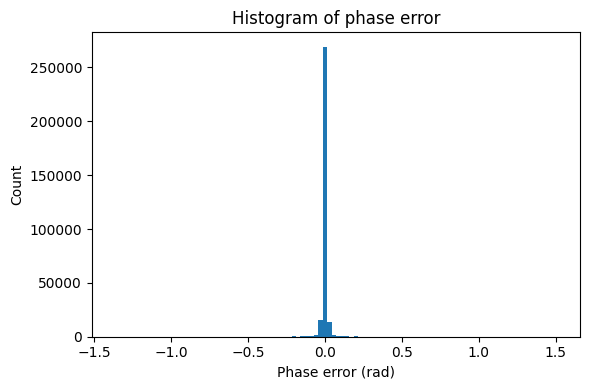

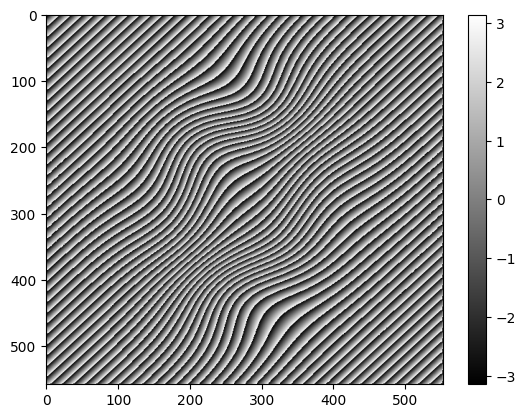

Phase RMSE (rad): 0.0523
Assertion passed: RMSE < 0.07 rad


In [4]:

# Demodulate and evaluate phase RMSE using hilbert filter numpy
f_demod_hilbert_2D_numpy = partial(DemodHilbert2D_NumPy, g, M, filter_orientation=fringe_carrier_or)

# Time Numpy hilbert 2D demodulation method (outputs kept if needed)
res__demod_hilbert_2D_numpy = time_function(f_demod_hilbert_2D_numpy.func.__name__, f_demod_hilbert_2D_numpy, n_runs=10, verbose=True)

#calculate phasor
pred_z = f_demod_hilbert_2D_numpy()

error_map_phi = np.angle(pred_z / z)
mask = M.astype(bool)

# Plot histogram of phase error
plt.figure(figsize=(6, 4))
plt.hist(error_map_phi[mask].ravel(), bins=100)
plt.xlabel("Phase error (rad)")
plt.ylabel("Count")
plt.title("Histogram of phase error")
plt.tight_layout()
plt.show()

plt.imshow(np.angle(pred_z), aspect='auto', cmap='gray')
plt.colorbar()
plt.show()


rmse_phi = np.sqrt(np.mean(error_map_phi[mask] ** 2))
print(f"Phase RMSE (rad): {rmse_phi:.4f}")
assert rmse_phi < 0.07, "RMSE condition failed (rmse_phi >= 0.02 rad)"
print("Assertion passed: RMSE < 0.07 rad")




[DemodHilbert2D_TF] Warm-up time: 52.65 ms
[DemodHilbert2D_TF] Run 1/10: 8.12 ms
[DemodHilbert2D_TF] Run 2/10: 8.34 ms
[DemodHilbert2D_TF] Run 3/10: 7.02 ms
[DemodHilbert2D_TF] Run 4/10: 7.36 ms
[DemodHilbert2D_TF] Run 5/10: 6.54 ms
[DemodHilbert2D_TF] Run 6/10: 6.67 ms
[DemodHilbert2D_TF] Run 7/10: 6.79 ms
[DemodHilbert2D_TF] Run 8/10: 6.87 ms
[DemodHilbert2D_TF] Run 9/10: 7.13 ms
[DemodHilbert2D_TF] Run 10/10: 6.48 ms
DemodHilbert2D_TF: 10 runs -> mean = 7.13 ms, std = 0.61 ms


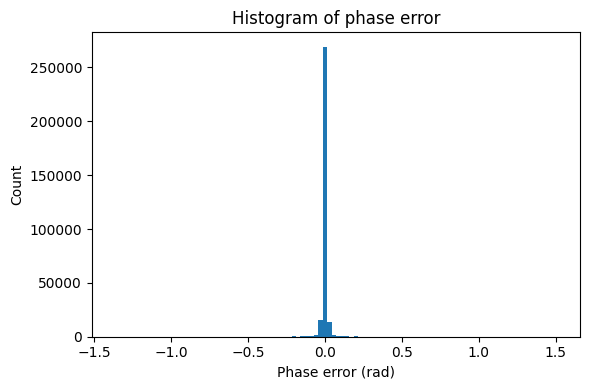

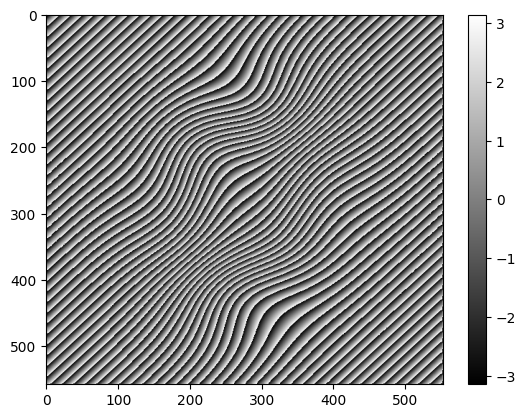

Phase RMSE (rad): 0.0523
Assertion passed: RMSE < 0.07 rad


In [5]:
# Demodulate and evaluate phase RMSE using hilbert filter tensor flow
f_demod_hilbert_2D_TF = partial(DemodHilbert2D_TF, g, M, filter_orientation=fringe_carrier_or)

# Time tensor flow hilbert 2D demodulation method (outputs kept if needed)
res__demod_hilbert_2D_TF = time_function(f_demod_hilbert_2D_TF.func.__name__, f_demod_hilbert_2D_TF, n_runs=10, verbose=True)

#calculate phasor
pred_z = f_demod_hilbert_2D_TF()


error_map_phi = np.angle(pred_z / z)
mask = M.astype(bool)


# Plot histogram of phase error
plt.figure(figsize=(6, 4))
plt.hist(error_map_phi[mask].ravel(), bins=100)
plt.xlabel("Phase error (rad)")
plt.ylabel("Count")
plt.title("Histogram of phase error")
plt.tight_layout()
plt.show()

plt.imshow(np.angle(pred_z), aspect='auto', cmap='gray')
plt.colorbar()
plt.show()


rmse_phi = np.sqrt(np.mean(error_map_phi[mask] ** 2))
print(f"Phase RMSE (rad): {rmse_phi:.4f}")
assert rmse_phi < 0.07, "RMSE condition failed (rmse_phi >= 0.02 rad)"
print("Assertion passed: RMSE < 0.07 rad")